In [1]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pathUVW = Path('/work/bk1450/b383184/Amazon/Mercator/data/variables_c')

In [3]:
ds_Hgr = xr.open_dataset('../data/Hgr_mesh.nc')
ds_Hgr

<xarray.Dataset> Size: 1GB
Dimensions:       (y: 3059, x: 4322, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/21)
    nav_lon       (y, x) float32 53MB ...
    nav_lat       (y, x) float32 53MB ...
    nav_lev       (z) float32 200B ...
    time_counter  (t) float64 8B ...
    glamt         (t, y, x) float32 53MB ...
    glamu         (t, y, x) float32 53MB ...
    ...            ...
    e1f           (t, y, x) float64 106MB ...
    e2t           (t, y, x) float64 106MB ...
    e2u           (t, y, x) float64 106MB ...
    e2v           (t, y, x) float64 106MB ...
    e2f           (t, y, x) float64 106MB ...
    ff            (t, y, x) float64 106MB ...
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

In [4]:
ds_Zgr = xr.open_dataset('../data/Zgr_cmesh.nc')
ds_Zgr

<xarray.Dataset> Size: 26MB
Dimensions:       (y: 499, x: 1260, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/13)
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
    nav_lev       (z) float32 200B ...
    time_counter  (t) float64 8B ...
    mbathy        (t, y, x) int16 1MB ...
    hdept         (t, y, x) float64 5MB ...
    ...            ...
    e3t_ps        (t, y, x) float64 5MB ...
    e3w_ps        (t, y, x) float64 5MB ...
    gdept_0       (t, z) float64 400B ...
    gdepw_0       (t, z) float64 400B ...
    e3t_0         (t, z) float64 400B ...
    e3w_0         (t, z) float64 400B ...
Attributes:
    file_name:            mesh_zgr.nc
    TimeStamp:            03/02/2016 10:24:41 -0000
    Unlimited_Dimension:  t

In [34]:
ds_Zgr.e3t_0.isel(t=0)

<xarray.DataArray 'e3t_0' (z: 50)> Size: 400B
[50 values with dtype=float64]
Dimensions without coordinates: z

In [24]:
Nz = ds_Hgr.nav_lev.size
# Ny = ds_Hgr.nav_lat.data
# Nx = ds_Hgr.nav_lon.data

mbathy = ds_Zgr.mbathy.isel(t=0)

Ny, Nx = mbathy.shape

In [28]:
tmask = np.zeros((Nz,Ny,Nx))

(50, 499, 1260)

In [30]:
for j in range(Ny):
    for i in range(Nx):
        kbot = int(mbathy[j,i]) #bottom level
        if kbot > 0:
            #wet levels
            tmask[0:kbot, j, i] = 1
        else:
            tmask[0:kbot, j, i] = 0
            

In [33]:
tmask_ds = xr.DataArray(
    tmask,
    dims=('z','y','x'),
    coords = {
        'z': ('z', ds_Hgr.nav_lev.values),
        'y': np.arange(Ny),
        'x': np.arange(Nx),
    },
    name='tmask'
)
tmask_ds

<xarray.DataArray 'tmask' (z: 50, y: 499, x: 1260)> Size: 251MB
array([[[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(50, 499, 1260))
Coordinates:
  * z        (z) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * y        (y) int64 4kB 0 1 2 3 4 5 6 7 8 ... 491 492 493 494 495 496 497 498
  * x        (x) int64 10kB 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259

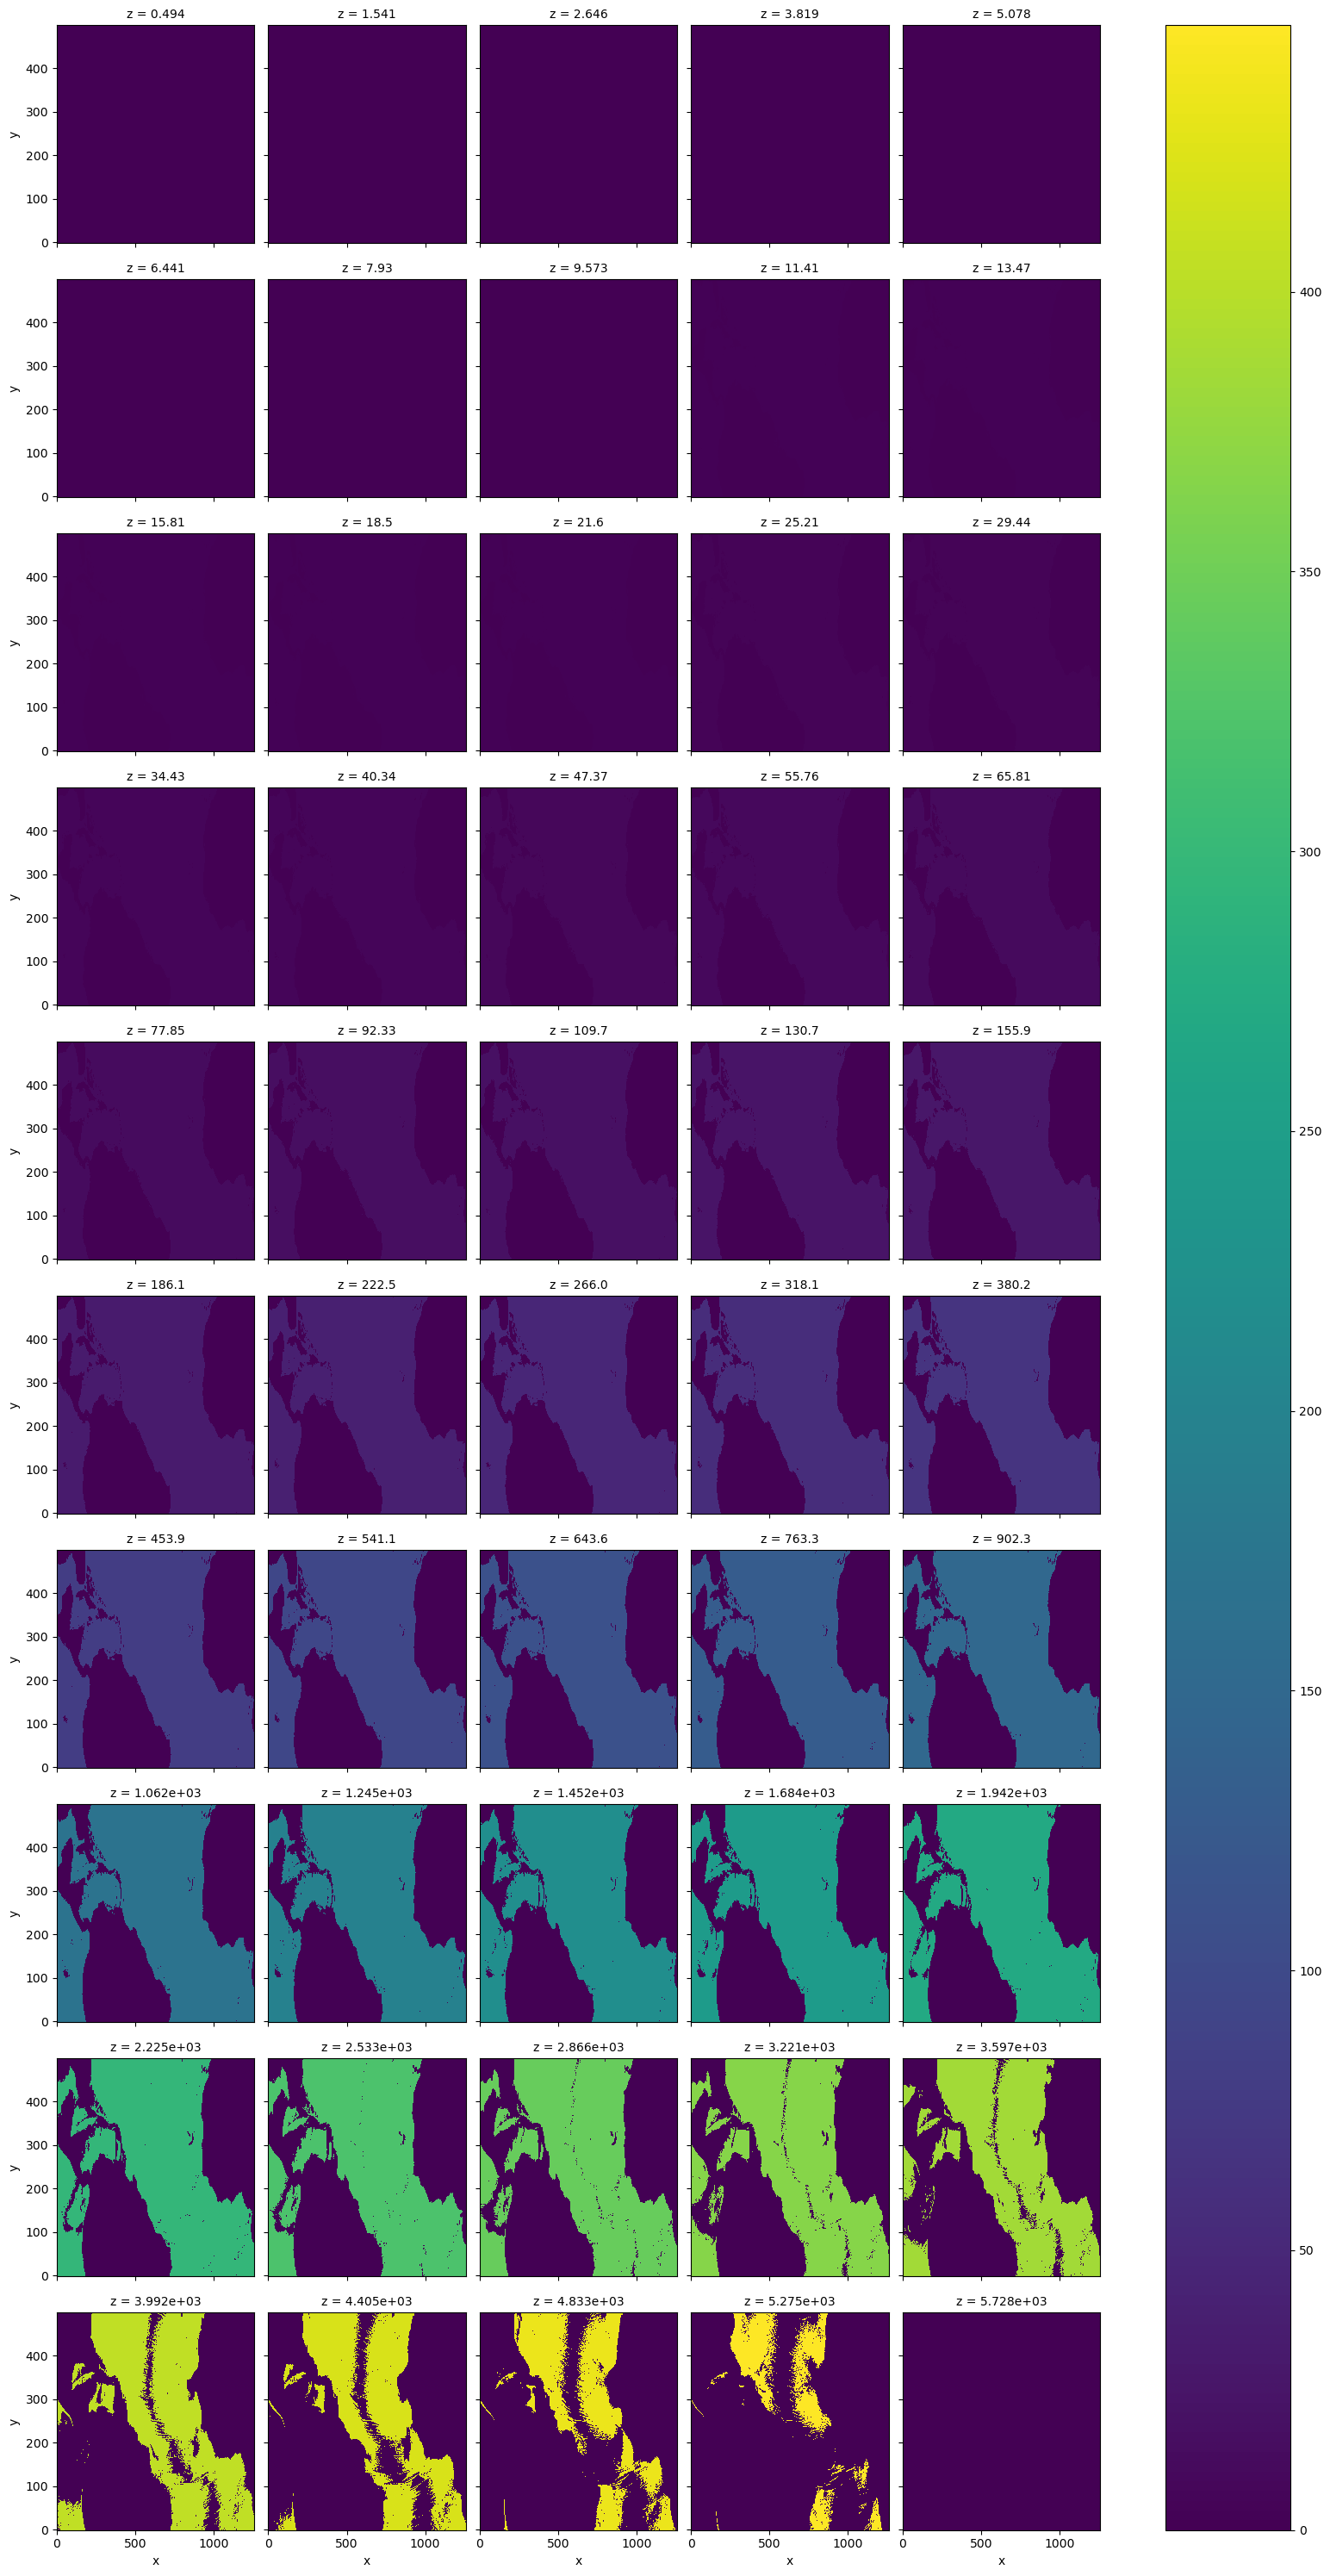

In [38]:
mask = tmask_ds*ds_Zgr.e3t_0.isel(t=0)
mask.plot(col='z',col_wrap=5)

## Now we fix the W

In [42]:
ds_ssh = xr.open_dataset(pathUVW / "SSH_1993-01c.nc")
ds_ssh

<xarray.Dataset> Size: 83MB
Dimensions:       (time_counter: 31, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
Data variables:
    sossheig      (time_counter, y, x) float32 78MB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Nov 10 14:48:52 2025: cdo setmissval,nan SSH_1993-01.nc...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [43]:
ds_W = xr.open_dataset(pathUVW / "W_1993-01c.nc")
ds_W

<xarray.Dataset> Size: 4GB
Dimensions:       (time_counter: 31, y: 499, x: 1260, depthw: 50)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
Data variables:
    vovecrtz      (time_counter, depthw, y, x) float32 4GB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:26:13 2025: cdo setmissval,nan W_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [44]:
deta_dt = ds_W.isel(depthw=0, drop=True)

In [45]:
z = - ds_W.depthw  # pos upward

In [46]:
H = ds_Zgr.isel(t=0).hdepw 

In [ ]:
eta = ds_ssh.sossheig

In [ ]:
W_eta = (z + H) / (eta + H) * deta_dt 

In [ ]:
W_eta